<a href="https://colab.research.google.com/github/TakashiNishii/CursoIA/blob/main/ClusterAdvance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Técnicas avançadas para cluster
hopkins, metricas e visual assesment of tendecy para avaliar os clusters

Códigos importados disponiveis em:

*   [hopkins.py](https://github.com/TakashiNishii/CursoIA/blob/main/hopkins.py)
*   [metrics.py](https://github.com/TakashiNishii/CursoIA/blob/main/metric.py)
*   [visual_assessment_of_tendency.py](https://github.com/TakashiNishii/CursoIA/blob/main/visual_assessment_of_tendency.py)



In [3]:
from sklearn import datasets
import numpy as np
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
from hopkins import *
from metric import *
from visual_assessment_of_tendency import *

In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
iris = datasets.load_iris()
clust1 = scale(iris.data)
clust2 = scale(np.random.rand(150,4))

In [7]:
print(clust2)

[[ 1.39183926e+00 -1.85012127e-01  1.38415223e+00  5.31574412e-01]
 [ 1.91107066e-01  1.29743247e+00  6.55764260e-01 -8.74277025e-01]
 [ 3.69171535e-01 -6.90002629e-02  1.19888082e+00  1.34473606e+00]
 [ 7.37277867e-01  3.41610603e-01 -1.53876044e+00  7.86667556e-01]
 [-5.91176275e-01 -1.27592857e+00  1.67457764e+00  1.38187770e+00]
 [-1.36094967e+00 -1.12643395e+00 -2.09524221e-01  1.35834415e+00]
 [ 1.24572576e+00  1.54293355e+00 -1.56588578e+00 -1.02550225e+00]
 [-1.33842910e+00  1.46158063e+00  7.72295316e-01 -8.95189176e-01]
 [-1.64405969e+00  8.25734852e-01 -3.95064659e-01  1.28885623e+00]
 [ 6.38137294e-01  1.63529729e+00 -7.11481927e-01 -1.58012577e+00]
 [-1.68034472e+00 -1.32518228e+00  4.79440709e-01 -4.26391916e-01]
 [ 1.32268881e+00  9.25880188e-01 -1.05208796e+00 -1.53786261e+00]
 [-4.77180743e-01  7.10669685e-01 -5.35324664e-01  1.41360012e-01]
 [-5.33877430e-01  2.23833118e-01 -6.11942690e-01 -4.40452370e-01]
 [-3.39716056e-01  1.17612542e+00 -8.17068677e-01  1.51416447e

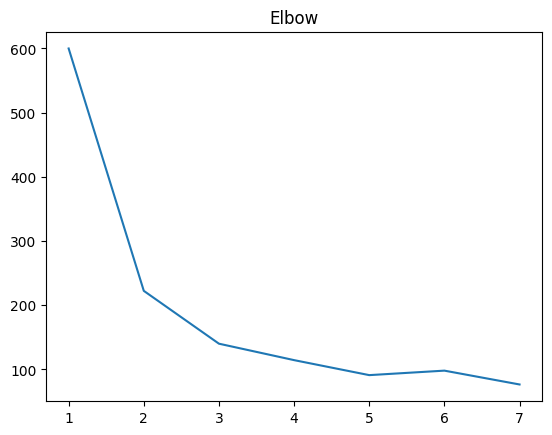

In [8]:
inertia = []
for i in range(1,8):
  kmeans = KMeans(n_clusters=i, n_init='auto')
  kmeans.fit(clust1)
  inertia.append(kmeans.inertia_)
plt.plot(range(1,8), inertia)
plt.title("Elbow")
plt.show()

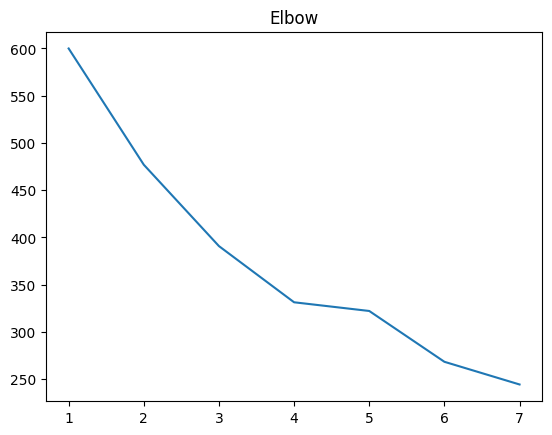

In [9]:
inertia = []
for i in range(1,8):
  kmeans = KMeans(n_clusters=i, n_init='auto')
  kmeans.fit(clust2)
  inertia.append(kmeans.inertia_)
plt.plot(range(1,8), inertia)
plt.title("Elbow")
plt.show()

In [10]:
hopkins(clust1, 150)

np.float64(0.17889682362715384)

In [11]:
hopkins(clust2, 150)

np.float64(0.502160165270051)

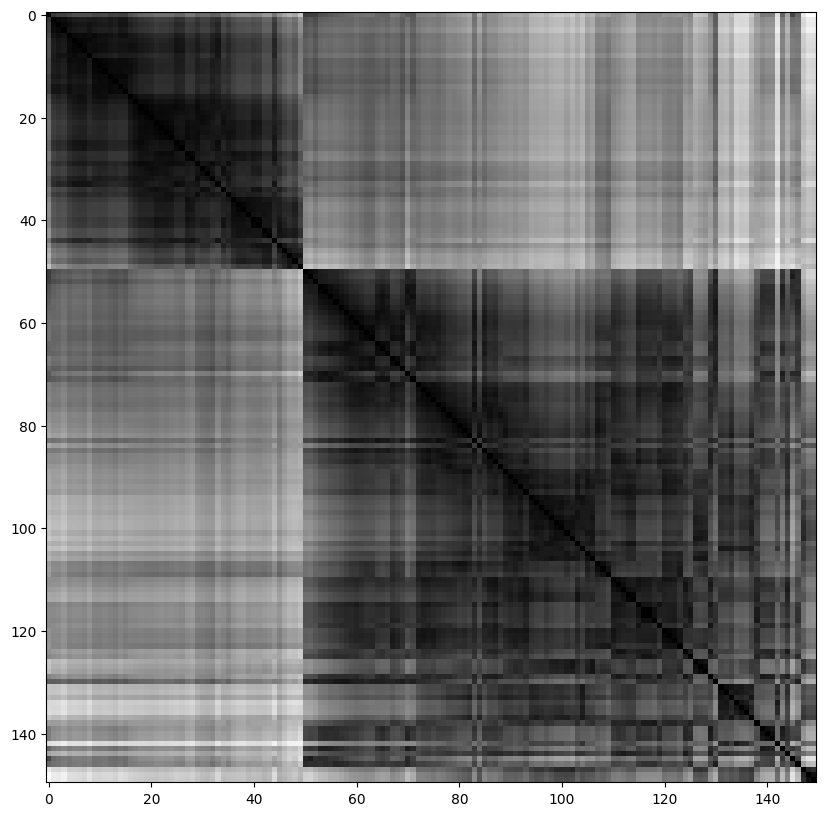

In [12]:
## Não tem um padrão nos dados
vat(clust1)

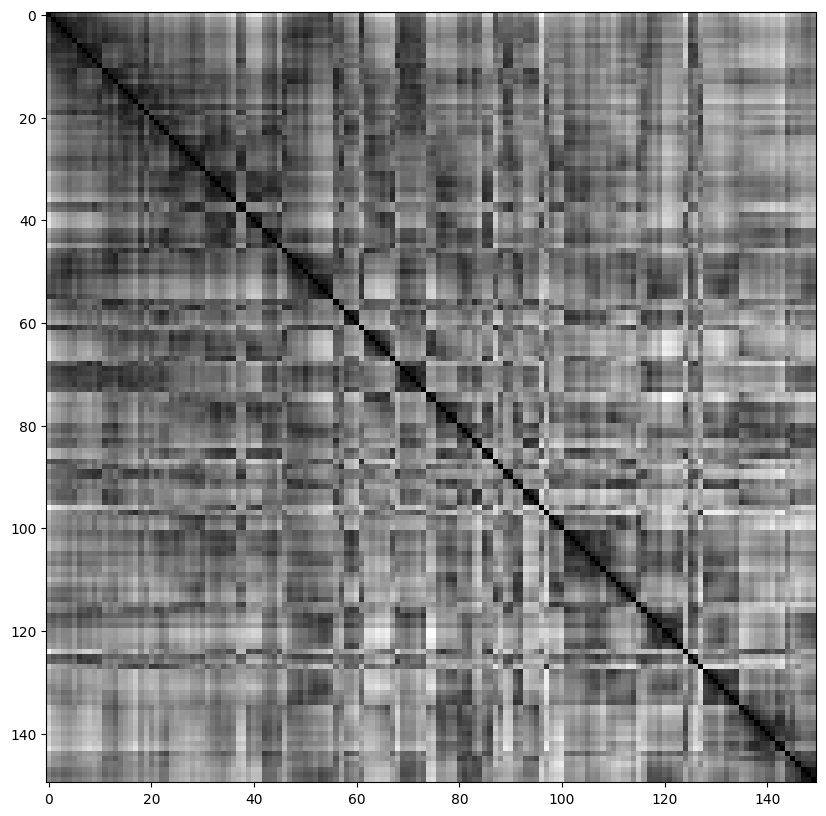

In [13]:
vat(clust2)

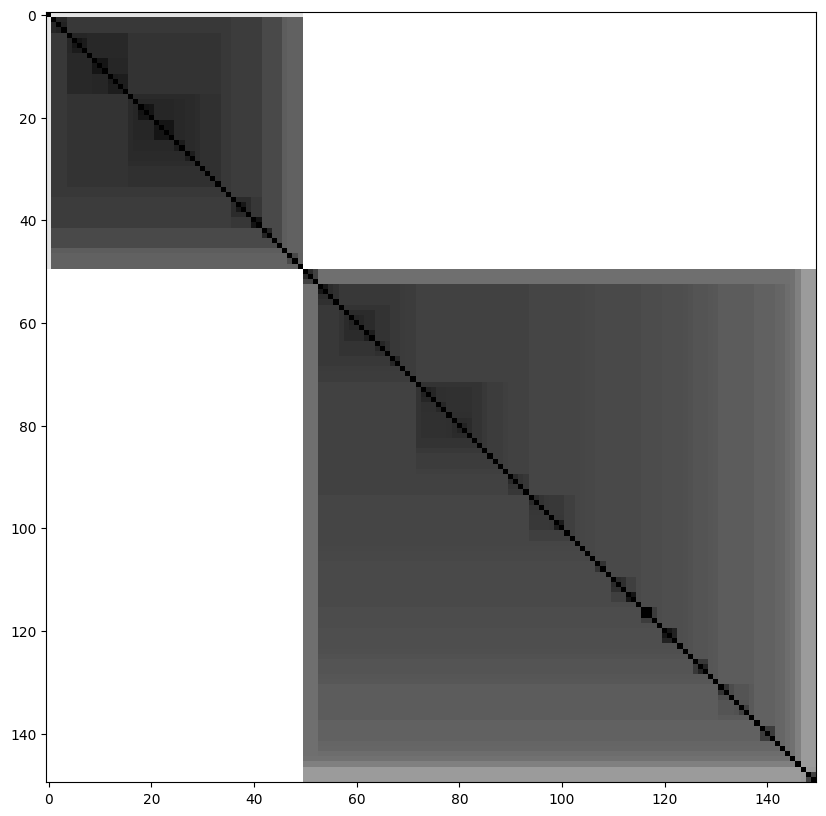

In [14]:
ivat(clust1)

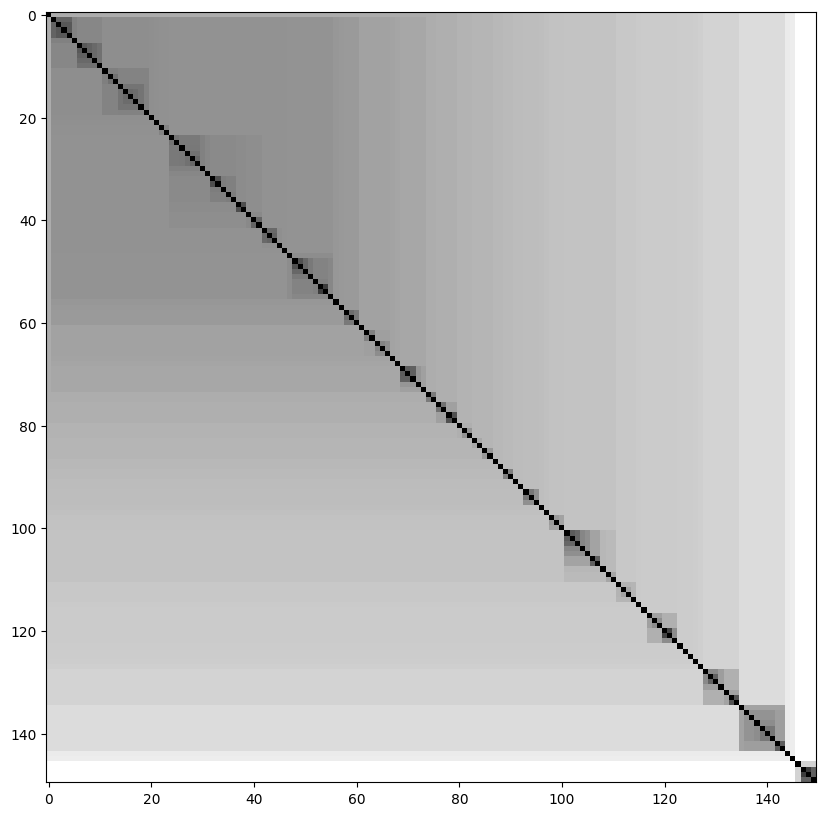

In [16]:
ivat(clust2)

In [20]:
# m = assess_tendency_by_metric(clust1, 'silhouette', 5)
# m = assess_tendency_by_metric(clust1, 'davies_bouldin', 5)
m = assess_tendency_by_metric(clust1, 'calinski_harabasz', 5)
print(m)

(np.int64(2), array([251.34933946, 239.48453205, 206.2286231 , 170.25805022]))


In [23]:
# m = assess_tendency_by_metric(clust2, 'silhouette', 5)
# m = assess_tendency_by_metric(clust2, 'davies_bouldin', 5)
m = assess_tendency_by_metric(clust2, 'calinski_harabasz', 5)
print(m)

(np.int64(3), array([38.58353661, 40.50534519, 36.52012496, 39.26412554]))


In [25]:
m = assess_tendency_by_mean_metric_score(clust1, 5)
print(m)

2.0


In [26]:
m = assess_tendency_by_mean_metric_score(clust2, 5)
print(m)

3.6666666666666665
